<a href="https://colab.research.google.com/github/nantaaja/tugas-statistika/blob/main/NantaWiltaWijaya_Pertemuan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== TABEL FREKUENSI ===
col_0  Frekuensi
Grade           
A             13
AB             7
B              4
BC             1
C              5
F              1

=== STATISTIKA DESKRIPTIF ===
count              31.000000
mean               76.638710
std                13.507848
min                45.650000
25%                68.800000
50%                79.150000
75%                87.500000
max                94.150000
Standard Error      2.426081
Median             79.150000
Mode               77.150000
variance          182.461952
range              48.500000
skewness           -0.711833
kurtosis           -0.453107
Name: Nilai, dtype: float64


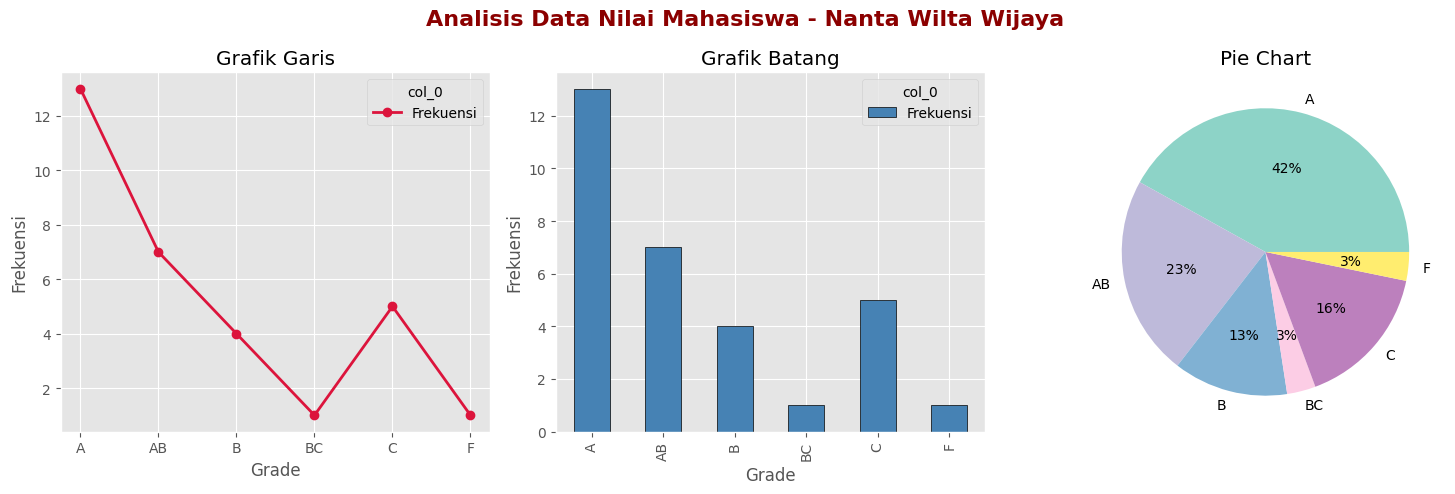

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


path = "nanta.xlsx"
dataraw = pd.read_excel(path)


dataraw.columns = ['ID', 'Name', 'KUIS', 'UTS', 'UAS', 'Nilai', 'Grade']


dataraw['KUIS'] = pd.to_numeric(dataraw['KUIS'], errors='coerce')
dataraw['UTS'] = pd.to_numeric(dataraw['UTS'], errors='coerce')
dataraw['UAS'] = pd.to_numeric(dataraw['UAS'], errors='coerce')
dataraw = dataraw.dropna(subset=['KUIS', 'UTS', 'UAS'])


dataraw['Nilai'] = (dataraw['KUIS'] * 0.35) + (dataraw['UTS'] * 0.30) + (dataraw['UAS'] * 0.35)

def hitung_grade(score):
    if score >= 81: return 'A'
    elif score >= 76: return 'AB'
    elif score >= 66: return 'B'
    elif score >= 61: return 'BC'
    elif score >= 51: return 'C'
    else: return 'F'

dataraw['Grade'] = dataraw['Nilai'].apply(hitung_grade)


datafrq = pd.crosstab(index=dataraw["Grade"], columns="Frekuensi")
print("=== TABEL FREKUENSI ===")
print(datafrq)


dt = dataraw["Nilai"]
stats = dt.describe()
stats['Standard Error'] = dt.sem()
stats['Median'] = dt.median()
stats['Mode'] = dt.mode().iloc[0]
stats['variance'] = dt.var()
stats['range'] = dt.max() - dt.min()
stats['skewness'] = dt.skew()
stats['kurtosis'] = dt.kurtosis()

print("\n=== STATISTIKA DESKRIPTIF ===")
print(stats)


plt.style.use('ggplot')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Analisis Data Nilai Mahasiswa - Nanta Wilta Wijaya', fontsize=16, fontweight='bold', color='darkred')


datafrq.plot(kind='line', ax=axes[0], marker='o', color='crimson', linewidth=2)
axes[0].set_title('Grafik Garis')
axes[0].set_ylabel('Frekuensi')


datafrq.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Grafik Batang')
axes[1].set_ylabel('Frekuensi')


datafrq.plot(kind='pie', y='Frekuensi', ax=axes[2], autopct='%1.0f%%', legend=False, cmap='Set3')
axes[2].set_title('Pie Chart')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()